# Full Explainability and Production

In [34]:
# IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import shap
import yfinance as yf
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from scipy import stats

# LOAD FEATURES
df_features = pd.read_parquet('processed_features.parquet')

print(f"Data loaded — shape: {df_features.shape}")
print(df_features.head())

Data loaded — shape: (1509, 61)
Price                        Close       High        Low       Open  \
Date                                                                  
1970-01-01 00:25:14.851  40.304176  40.313537  39.602258  39.812835   
1970-01-01 00:25:14.937  40.297161  40.839980  40.233991  40.367354   
1970-01-01 00:25:15.024  40.484325  40.587274  40.262052  40.369677   
1970-01-01 00:25:15.110  40.945259  41.031828  40.489013  40.580262   
1970-01-01 00:25:15.369  40.793182  41.087987  40.694911  40.793182   

Price                       Volume  return_1d  return_3d  return_5d  \
Date                                                                  
1970-01-01 00:25:14.851  102223600        NaN        NaN        NaN   
1970-01-01 00:25:14.937  118071600  -0.000174        NaN        NaN   
1970-01-01 00:25:15.024   89738400   0.004645        NaN        NaN   
1970-01-01 00:25:15.110   94640000   0.011385   0.015906        NaN   
1970-01-01 00:25:15.369   82271200  -0.00371

In [35]:
# TRAIN / HOLDOUT SPLIT (time-aware)
feature_cols = [col for col in df_features.columns if col != 'Target']

# Recreate Target: 1 if next-day close is up, else 0
df_features['Target'] = (df_features['return_1d'].shift(-1) > 0).astype(int)
df_features = df_features.dropna()

X = df_features[feature_cols]
y = df_features['Target']

split_idx = int(len(X) * 0.80)

X_train, X_holdout = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_holdout = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train  : {X_train.shape[0]} rows  ({X_train.index[0].date()} → {X_train.index[-1].date()})")
print(f"Holdout: {X_holdout.shape[0]} rows  ({X_holdout.index[0].date()} → {X_holdout.index[-1].date()})")


Train  : 1035 rows  (1970-01-01 → 1970-01-01)
Holdout: 259 rows  (1970-01-01 → 1970-01-01)


In [36]:
# TRAIN BASE XGBOOST
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_holdout, y_holdout)],
    verbose=50
)

print("Base model training complete.")

# HYPERPARAMETER TUNING + PIPELINE
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', xgb.XGBClassifier(
        eval_metric='logloss',
        random_state=42
    ))
])

param_dist = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 4, 5],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.7, 0.8, 0.9],
    'model__colsample_bytree': [0.7, 0.8, 0.9],
}

search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(X_train, y_train)

best_xgb = search.best_estimator_

print(f"Best params : {search.best_params_}")
print(f"Best AUC    : {search.best_score_:.4f}")


[0]	validation_0-logloss:0.68815
[50]	validation_0-logloss:0.74192
[100]	validation_0-logloss:0.77309
[150]	validation_0-logloss:0.81690
[200]	validation_0-logloss:0.83224
[250]	validation_0-logloss:0.85373
[299]	validation_0-logloss:0.86866
Base model training complete.
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params : {'model__subsample': 0.9, 'model__n_estimators': 300, 'model__max_depth': 3, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.9}
Best AUC    : 0.4466


In [18]:
# PREDICT PROBABILITIES ON HOLDOUT
tuned_proba = best_xgb.predict_proba(X_holdout)[:, 1]
tuned_preds = (tuned_proba > 0.5).astype(int)

print(f"Predicted proba — mean: {tuned_proba.mean():.3f}  "
      f"min: {tuned_proba.min():.3f}  "
      f"max: {tuned_proba.max():.3f}")


Predicted proba — mean: 0.429  min: 0.244  max: 0.651


In [24]:
# BACKTEST ENGINE
def full_backtest(signal_proba, actual_returns, threshold=0.5,
                  transaction_cost=0.001, name="Strategy"):
    """
    Full backtest engine with transaction costs and risk metrics.

    signal_proba:     model's predicted probability of an up day
    actual_returns:   the actual daily returns that occurred
    threshold:        probability above which we go long
    transaction_cost: 0.1% per trade (0.001) — realistic for retail
    """
    signals = (signal_proba > threshold).astype(int)
    prev_sig = signals.shift(1).fillna(0)
    trades = (signals != prev_sig).astype(int)

    strategy_returns = signals * actual_returns - trades * transaction_cost

    total_days = len(strategy_returns)
    trading_days_per_year = 252
    years = total_days / trading_days_per_year

    cum_return_strat = (1 + strategy_returns).prod() - 1
    ann_return = (1 + cum_return_strat) ** (1 / years) - 1
    ann_vol = strategy_returns.std() * np.sqrt(trading_days_per_year)

    rf_daily = 0.05 / trading_days_per_year
    excess = strategy_returns - rf_daily
    sharpe = (excess.mean() / excess.std()) * np.sqrt(trading_days_per_year)

    downside_returns = strategy_returns[strategy_returns < rf_daily]
    downside_vol = downside_returns.std() * np.sqrt(trading_days_per_year)
    sortino = (ann_return - 0.05) / downside_vol if downside_vol > 0 else np.nan

    cum_equity = (1 + strategy_returns).cumprod()
    rolling_max = cum_equity.cummax()
    drawdown = (cum_equity - rolling_max) / rolling_max
    max_dd = drawdown.min()
    calmar = ann_return / abs(max_dd) if max_dd != 0 else np.nan

    wins = strategy_returns[strategy_returns > 0]
    losses = strategy_returns[strategy_returns < 0]
    win_rate = len(wins) / len(strategy_returns[strategy_returns != 0])
    profit_factor = wins.sum() / abs(losses.sum()) if len(losses) > 0 else np.nan

    n_trades = trades.sum()
    days_in_mkt = signals.sum()

    print(f"\n{'=' * 50}")
    print(f"  {name}")
    print(f"{'=' * 50}")
    print(f"  Period:              {total_days} days ({years:.1f} years)")
    print(f"  Trades:              {n_trades}")
    print(f"  Days in market:      {days_in_mkt} ({days_in_mkt / total_days:.1%})")
    print(f"  ─────────────────────────────────────────")
    print(f"  Cumulative return:   {cum_return_strat:.2%}")
    print(f"  Annualized return:   {ann_return:.2%}")
    print(f"  Annualized vol:      {ann_vol:.2%}")
    print(f"  ─────────────────────────────────────────")
    print(f"  Sharpe Ratio:        {sharpe:.3f}")
    print(f"  Sortino Ratio:       {sortino:.3f}")
    print(f"  Calmar Ratio:        {calmar:.3f}")
    print(f"  Max Drawdown:        {max_dd:.2%}")
    print(f"  ─────────────────────────────────────────")
    print(f"  Win rate:            {win_rate:.2%}")
    print(f"  Profit factor:       {profit_factor:.3f}")
    print(f"{'=' * 50}")

    return {
        'cum_returns': cum_equity,
        'drawdown': drawdown,
        'strategy_rets': strategy_returns,
        'sharpe': sharpe,
        'max_dd': max_dd,
        'ann_return': ann_return
    }



In [25]:
# RUN BACKTEST
actual_rets_holdout = df_features.loc[X_holdout.index, 'return_1d']

backtest_result = full_backtest(
    signal_proba=pd.Series(tuned_proba, index=X_holdout.index),
    actual_returns=actual_rets_holdout,
    threshold=0.5,
    transaction_cost=0.001,
    name="XGBoost ML Strategy"
)

bh_result = full_backtest(
    signal_proba=pd.Series(np.ones(len(X_holdout)), index=X_holdout.index),
    actual_returns=actual_rets_holdout,
    threshold=0.5,
    transaction_cost=0,
    name="Buy and Hold (AAPL)"
)


  XGBoost ML Strategy
  Period:              259 days (1.0 years)
  Trades:              48
  Days in market:      45 (17.4%)
  ─────────────────────────────────────────
  Cumulative return:   -18.38%
  Annualized return:   -17.93%
  Annualized vol:      9.30%
  ─────────────────────────────────────────
  Sharpe Ratio:        -2.614
  Sortino Ratio:       -2.899
  Calmar Ratio:        -1.015
  Max Drawdown:        -17.66%
  ─────────────────────────────────────────
  Win rate:            23.19%
  Profit factor:       0.441

  Buy and Hold (AAPL)
  Period:              259 days (1.0 years)
  Trades:              1
  Days in market:      259 (100.0%)
  ─────────────────────────────────────────
  Cumulative return:   41.66%
  Annualized return:   40.33%
  Annualized vol:      20.83%
  ─────────────────────────────────────────
  Sharpe Ratio:        1.491
  Sortino Ratio:       2.652
  Calmar Ratio:        2.681
  Max Drawdown:        -15.04%
  ─────────────────────────────────────────
  

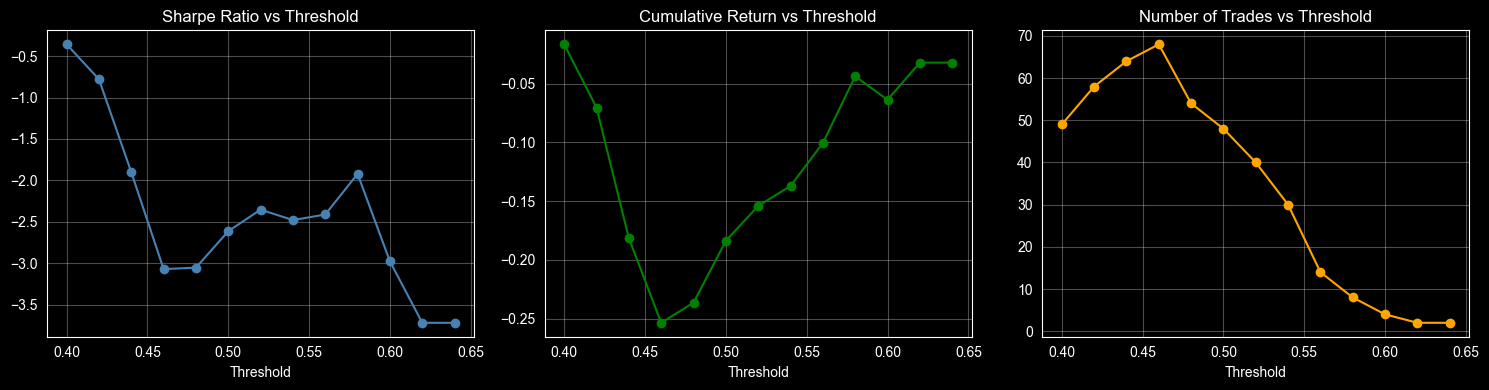


Optimal threshold : 0.40
           sharpe  cum_return  n_trades  pct_long
threshold                                        
0.40       -0.358      -0.017        49     0.602
0.42       -0.780      -0.070        58     0.514
0.44       -1.902      -0.182        64     0.417
0.46       -3.072      -0.253        68     0.317
0.48       -3.054      -0.236        54     0.236
0.50       -2.614      -0.184        48     0.174
0.52       -2.353      -0.154        40     0.147
0.54       -2.480      -0.137        30     0.097
0.56       -2.412      -0.101        14     0.046
0.58       -1.922      -0.044         8     0.023
0.60       -2.977      -0.064         4     0.012
0.62       -3.720      -0.032         2     0.008
0.64       -3.720      -0.032         2     0.008


In [26]:
# THRESHOLD OPTIMISATION
thresholds = np.arange(0.4, 0.65, 0.02)
threshold_results = []

for t in thresholds:
    signals = (pd.Series(tuned_proba) > t).astype(int)
    strat_returns = signals.values * actual_rets_holdout.values - \
                    (signals.values != np.roll(signals.values, 1)).astype(int) * 0.001
    strat_returns = pd.Series(strat_returns)
    rf = 0.05 / 252
    sharpe = ((strat_returns - rf).mean() / strat_returns.std()) * np.sqrt(252)
    cum_ret = (1 + strat_returns).prod() - 1
    threshold_results.append({
        'threshold': t,
        'sharpe': sharpe,
        'cum_return': cum_ret,
        'n_trades': (signals != signals.shift(1)).sum(),
        'pct_long': signals.mean()
    })

thresh_df = pd.DataFrame(threshold_results)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(thresh_df['threshold'], thresh_df['sharpe'], 'o-', color='steelblue')
axes[0].set_title('Sharpe Ratio vs Threshold')
axes[0].set_xlabel('Threshold');
axes[0].grid(True, alpha=0.3)

axes[1].plot(thresh_df['threshold'], thresh_df['cum_return'], 'o-', color='green')
axes[1].set_title('Cumulative Return vs Threshold')
axes[1].set_xlabel('Threshold');
axes[1].grid(True, alpha=0.3)

axes[2].plot(thresh_df['threshold'], thresh_df['n_trades'], 'o-', color='orange')
axes[2].set_title('Number of Trades vs Threshold')
axes[2].set_xlabel('Threshold');
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_thresh = thresh_df.loc[thresh_df['sharpe'].idxmax(), 'threshold']
print(f"\nOptimal threshold : {best_thresh:.2f}")
print(thresh_df.set_index('threshold').round(3))

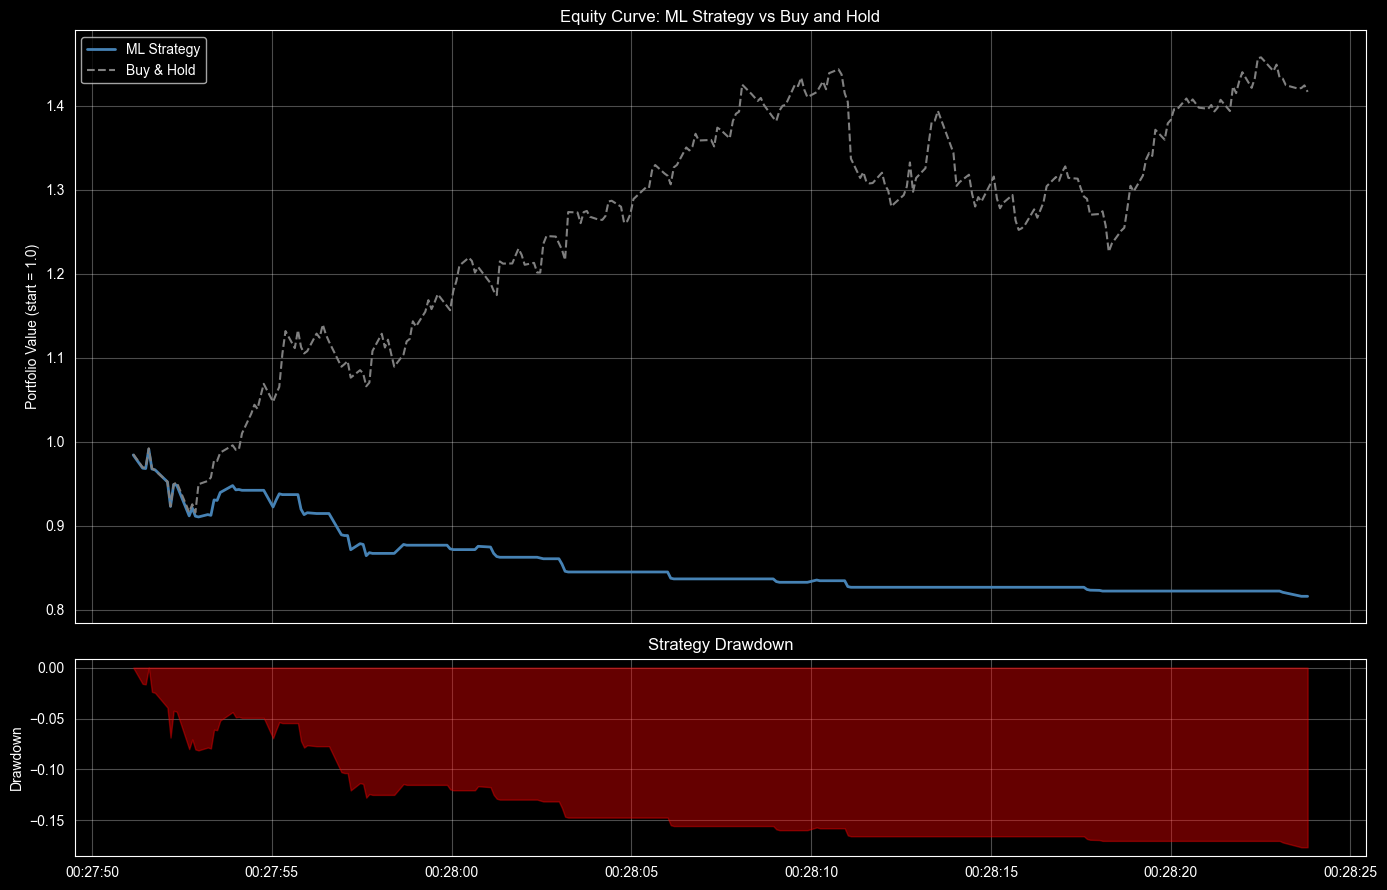

In [27]:
# EQUITY CURVE + DRAWDOWN PLOT
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(backtest_result['cum_returns'].index,
         backtest_result['cum_returns'].values,
         label='ML Strategy', color='steelblue', lw=2)
ax1.plot(bh_result['cum_returns'].index,
         bh_result['cum_returns'].values,
         label='Buy & Hold', color='gray', lw=1.5, ls='--')
ax1.set_title('Equity Curve: ML Strategy vs Buy and Hold')
ax1.set_ylabel('Portfolio Value (start = 1.0)')
ax1.legend();
ax1.grid(True, alpha=0.3)

ax2.fill_between(backtest_result['drawdown'].index,
                 backtest_result['drawdown'].values, 0,
                 color='red', alpha=0.4)
ax2.set_title('Strategy Drawdown')
ax2.set_ylabel('Drawdown')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


SHAP values computed — shape: (259, 61)
Explaining 259 predictions across 61 features



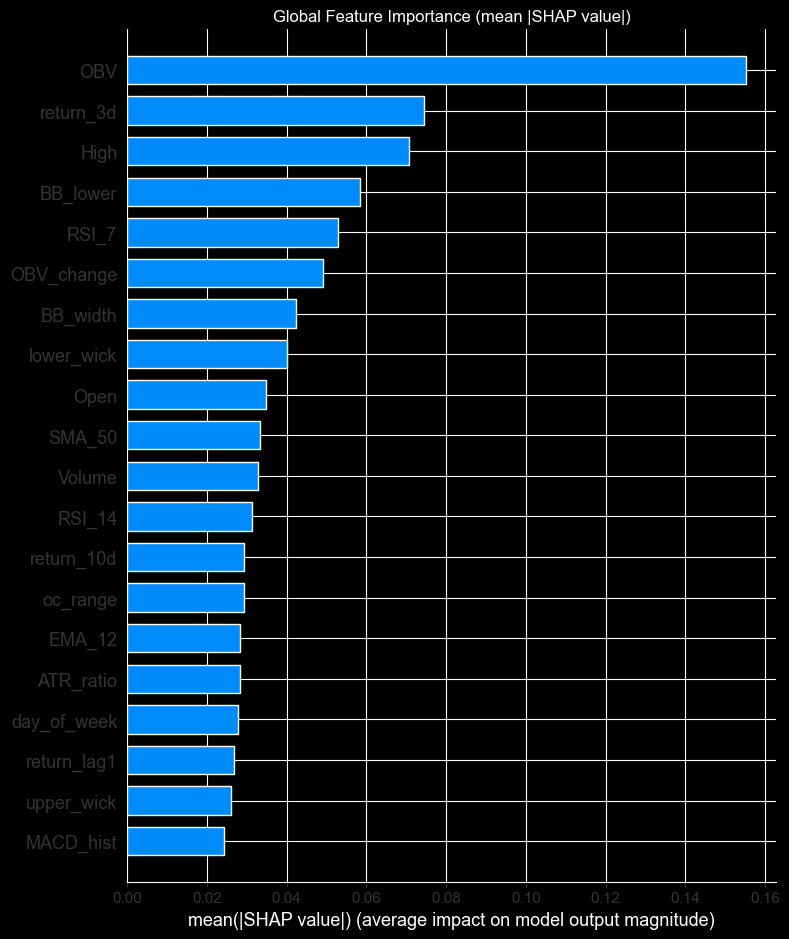

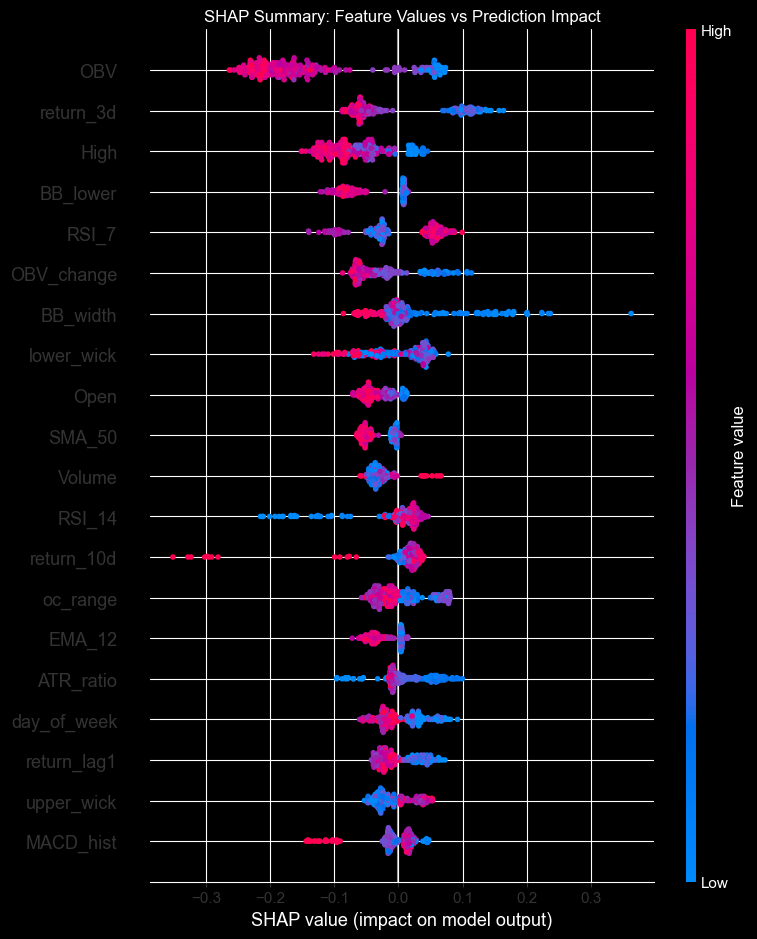

Top 10 features by mean |SHAP value|:
OBV           0.15511
return_3d     0.07450
High          0.07068
BB_lower      0.05837
RSI_7         0.05288
OBV_change    0.04902
BB_width      0.04248
lower_wick    0.04019
Open          0.03476
SMA_50        0.03325


In [28]:
# SHAP — GLOBAL EXPLAINABILITY
best_model = best_xgb.named_steps['model']
best_scaler = best_xgb.named_steps['scaler']

X_holdout_scaled = best_scaler.transform(X_holdout)
X_holdout_df = pd.DataFrame(
    X_holdout_scaled,
    columns=feature_cols,
    index=X_holdout.index
)

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_holdout_df)

print(f"SHAP values computed — shape: {shap_values.shape}")
print(f"Explaining {X_holdout_df.shape[0]} predictions "
      f"across {X_holdout_df.shape[1]} features\n")

# Plot 1: Global importance (mean |SHAP|)
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_holdout_df,
    feature_names=feature_cols,
    plot_type="bar",
    show=False
)
plt.title("Global Feature Importance (mean |SHAP value|)")
plt.tight_layout()
plt.show()

# Plot 2: Beeswarm — feature value vs prediction impact
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_holdout_df,
    feature_names=feature_cols,
    show=False
)
plt.title("SHAP Summary: Feature Values vs Prediction Impact")
plt.tight_layout()
plt.show()

# Top 10 by mean |SHAP|
mean_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=feature_cols
).sort_values(ascending=False)

print("Top 10 features by mean |SHAP value|:")
print(mean_shap.head(10).round(5).to_string())



Explaining prediction for : 1970-01-01
Model predicted           : Up
Actual outcome            : Down
Confidence (proba)        : 0.643


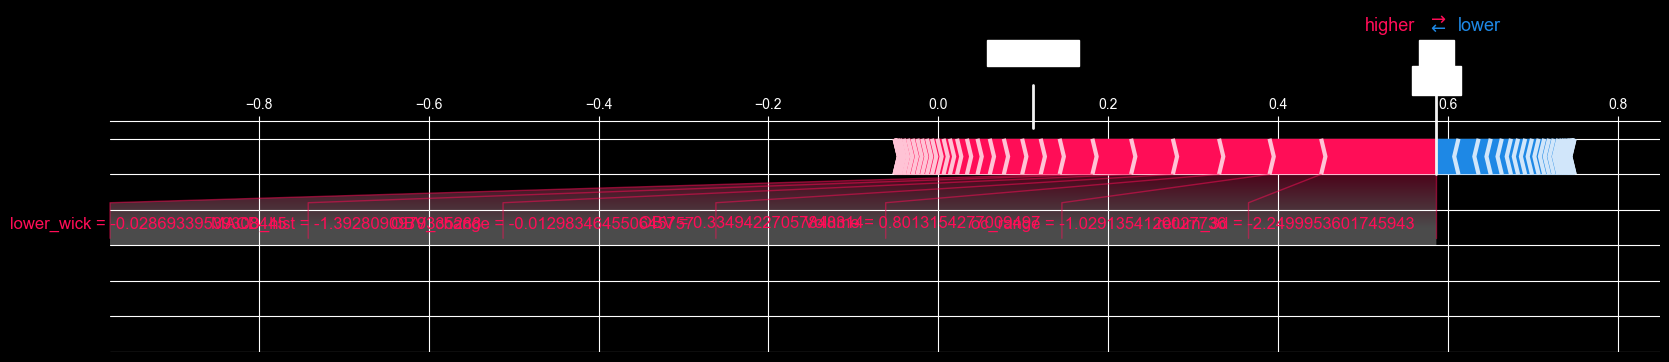

In [29]:
# SHAP — LOCAL EXPLAINABILITY
# Explain the first wrong prediction — most instructive case
wrong_idx = np.where(tuned_preds != y_holdout.values)[0]
sample_idx = wrong_idx[0]

print(f"\nExplaining prediction for : {X_holdout.index[sample_idx].date()}")
print(f"Model predicted           : {'Up' if tuned_preds[sample_idx] == 1 else 'Down'}")
print(f"Actual outcome            : {'Up' if y_holdout.iloc[sample_idx] == 1 else 'Down'}")
print(f"Confidence (proba)        : {tuned_proba[sample_idx]:.3f}")

shap.force_plot(
    explainer.expected_value,
    shap_values[sample_idx],
    X_holdout_df.iloc[sample_idx],
    feature_names=feature_cols,
    matplotlib=True,
    show=True
)


In [31]:
# DEFINE build_features (required by production pipeline)  FROM PHASE 3

def build_features(df_input, spy_input):
    """
    Master feature engineering function.
    Takes raw OHLCV data and returns a rich feature DataFrame.
    Must match exactly what was used during training.
    """
    df  = df_input.copy()
    spy = spy_input.copy()

    # RETURNS
    df['return_1d']  = df['Close'].pct_change(1)
    df['return_3d']  = df['Close'].pct_change(3)
    df['return_5d']  = df['Close'].pct_change(5)
    df['return_10d'] = df['Close'].pct_change(10)
    df['return_20d'] = df['Close'].pct_change(20)

    for lag in [1, 2, 3, 5]:
        df[f'return_lag{lag}'] = df['return_1d'].shift(lag)

    # TREND
    for window in [5, 10, 20, 50, 200]:
        df[f'SMA_{window}'] = df['Close'].rolling(window).mean()

    df['price_vs_SMA10']  = df['Close'] / df['SMA_10']  - 1
    df['price_vs_SMA50']  = df['Close'] / df['SMA_50']  - 1
    df['price_vs_SMA200'] = df['Close'] / df['SMA_200'] - 1
    df['SMA10_vs_SMA50']  = df['SMA_10'] / df['SMA_50'] - 1

    df['EMA_12'] = df['Close'].ewm(span=12, adjust=False).mean()
    df['EMA_26'] = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD']        = df['EMA_12'] - df['EMA_26']
    df['MACD_signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['MACD_hist']   = df['MACD'] - df['MACD_signal']

    # ── MOMENTUM ─────────────────────────────────────────────
    def compute_rsi(series, period=14):
        delta = series.diff()
        gain  = delta.clip(lower=0).rolling(period).mean()
        loss  = (-delta.clip(upper=0)).rolling(period).mean()
        rs    = gain / loss.replace(0, np.nan)
        return 100 - (100 / (1 + rs))

    df['RSI_14']        = compute_rsi(df['Close'], 14)
    df['RSI_7']         = compute_rsi(df['Close'], 7)
    df['RSI_14_change'] = df['RSI_14'].diff()
    df['RSI_vs_50']     = df['RSI_14'] - 50
    df['ROC_5']         = df['Close'].pct_change(5)  * 100
    df['ROC_20']        = df['Close'].pct_change(20) * 100

    # VOLATILITY
    df['vol_5d']    = df['return_1d'].rolling(5).std()  * np.sqrt(252)
    df['vol_20d']   = df['return_1d'].rolling(20).std() * np.sqrt(252)
    df['vol_60d']   = df['return_1d'].rolling(60).std() * np.sqrt(252)
    df['vol_ratio'] = df['vol_5d'] / df['vol_20d']

    bb_mid = df['Close'].rolling(20).mean()
    bb_std = df['Close'].rolling(20).std()
    df['BB_upper']    = bb_mid + 2 * bb_std
    df['BB_lower']    = bb_mid - 2 * bb_std
    df['BB_width']    = (df['BB_upper'] - df['BB_lower']) / bb_mid
    df['BB_position'] = (df['Close'] - df['BB_lower']) / (df['BB_upper'] - df['BB_lower'])

    df['TR'] = np.maximum(
        df['High'] - df['Low'],
        np.maximum(
            abs(df['High'] - df['Close'].shift(1)),
            abs(df['Low']  - df['Close'].shift(1))
        )
    )
    df['ATR_14']    = df['TR'].rolling(14).mean()
    df['ATR_ratio'] = df['ATR_14'] / df['Close']

    # VOLUME
    df['vol_ratio_20'] = df['Volume'] / df['Volume'].rolling(20).mean()

    obv = [0]
    for i in range(1, len(df)):
        if df['Close'].iloc[i] > df['Close'].iloc[i-1]:
            obv.append(obv[-1] + df['Volume'].iloc[i])
        elif df['Close'].iloc[i] < df['Close'].iloc[i-1]:
            obv.append(obv[-1] - df['Volume'].iloc[i])
        else:
            obv.append(obv[-1])
    df['OBV']        = obv
    df['OBV_change'] = df['OBV'].pct_change(5)

    df['VWAP_ratio'] = df['Close'] / (
        (df['Close'] * df['Volume']).rolling(20).sum() /
        df['Volume'].rolling(20).sum()
    )

    # INTRADAY
    df['hl_range']   = (df['High'] - df['Low'])  / df['Close']
    df['oc_range']   = (df['Close'] - df['Open']) / df['Open']
    df['upper_wick'] = (df['High'] - np.maximum(df['Open'], df['Close'])) / df['Close']
    df['lower_wick'] = (np.minimum(df['Open'], df['Close']) - df['Low'])  / df['Close']

    # MARKET (SPY)
    spy['spy_return_1d'] = spy['Close'].pct_change(1)
    spy['spy_return_5d'] = spy['Close'].pct_change(5)
    df['spy_return_1d']  = spy['spy_return_1d'].reindex(df.index)
    df['spy_return_5d']  = spy['spy_return_5d'].reindex(df.index)
    df['rel_strength_5d'] = df['return_5d'] - df['spy_return_5d']

    # CALENDAR
    df['day_of_week']    = df.index.dayofweek
    df['month']          = df.index.month
    df['quarter']        = df.index.quarter
    df['is_month_end']   = df.index.is_month_end.astype(int)
    df['is_quarter_end'] = df.index.is_quarter_end.astype(int)

    return df

In [33]:
# PRODUCTION PREDICTION PIPELINE
class QuantPredictionPipeline:
    """
    Production-ready wrapper around the trained ML model.
    Given a ticker, downloads latest data, engineers features,
    and returns a trading signal with SHAP-based explanation.
    """

    def __init__(self, model, scaler, feature_cols, spy_ticker="SPY"):
        self.model = model
        self.scaler = scaler
        self.feature_cols = feature_cols
        self.spy_ticker = spy_ticker

    def get_latest_signal(self, ticker, lookback_days=300):
        """
        Returns:
            signal      : 1 (go long) or 0 (stay out)
            confidence  : probability of an up day
            top_drivers : top 3 SHAP features driving the prediction
        """
        end_date = pd.Timestamp.today()
        start_date = end_date - pd.Timedelta(days=lookback_days)

        raw = yf.download(ticker, start=start_date, end=end_date,
                          auto_adjust=True, progress=False)
        spy = yf.download(self.spy_ticker, start=start_date, end=end_date,
                          auto_adjust=True, progress=False)

        # Flatten MultiIndex columns (newer yfinance versions)
        raw.columns = raw.columns.get_level_values(0)
        spy.columns = spy.columns.get_level_values(0)

        if len(raw) < 60:
            raise ValueError(f"Not enough data for {ticker} — need at least 60 rows")

        # Engineer features using same function as training
        featured = build_features(raw, spy)

        # Get most recent complete row
        latest = featured[self.feature_cols].dropna().iloc[[-1]]

        # Scale and predict
        latest_scaled = self.scaler.transform(latest)
        proba = self.model.predict_proba(latest_scaled)[0, 1]
        signal = int(proba > 0.5)

        # SHAP explanation for this single prediction
        exp = shap.TreeExplainer(self.model)
        shap_vals = exp.shap_values(
            pd.DataFrame(latest_scaled, columns=self.feature_cols)
        )
        top_idx = np.argsort(np.abs(shap_vals[0]))[::-1][:3]
        top_drivers = [
            (self.feature_cols[i], round(shap_vals[0][i], 4))
            for i in top_idx
        ]

        return {
            'ticker': ticker,
            'date': latest.index[0].date(),
            'signal': signal,
            'confidence': round(proba, 4),
            'action': "BUY / HOLD LONG" if signal == 1 else "STAY OUT / FLAT",
            'top_drivers': top_drivers
        }


# Instantiate and run
quant_pipeline = QuantPredictionPipeline(
    model=best_model,
    scaler=best_scaler,
    feature_cols=feature_cols
)

result = quant_pipeline.get_latest_signal("AAPL")

print("\n" + "=" * 50)
print(f"  LIVE PREDICTION for {result['ticker']}")
print("=" * 50)
print(f"  Date       : {result['date']}")
print(f"  Signal     : {result['signal']}")
print(f"  Action     : {result['action']}")
print(f"  Confidence : {result['confidence']:.1%}")
print(f"\n  Top prediction drivers:")
for feat, shap_val in result['top_drivers']:
    direction = "▲ pushes UP" if shap_val > 0 else "▼ pushes DOWN"
    print(f"    {feat:25s}  {direction}  (SHAP: {shap_val:+.4f})")
print("=" * 50)


  LIVE PREDICTION for AAPL
  Date       : 2026-05-05
  Signal     : 0
  Action     : STAY OUT / FLAT
  Confidence : 41.9%

  Top prediction drivers:
    High                       ▼ pushes DOWN  (SHAP: -0.1357)
    BB_lower                   ▼ pushes DOWN  (SHAP: -0.0895)
    OBV                        ▲ pushes UP  (SHAP: +0.0752)
